In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Configuration dictionary
config = {
    'tickers': ['AAPL', 'GOOGL', 'AMZN', 'TSLA', 'BTC-USD', 'ETH-USD'],
    'data_length': 1000,  # Number of data points to fetch until now
    'data_interval': '1d',  # 1m, 1h, 1d, 1wk, 1mo
    'predict_horizon': 10,
    'data_path': './data/',
    'save_path': './log/',
    'learning_rate': 0.001,
    'epochs': 1000,
    'sequence_length': 30,  # Number of time steps to look back
    'hidden_size': 128,
    'num_layers': 2,
    'output_size': 1,
    'test_size': 0.2,  # 20% of data for testing
    'batch_size': 16,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

In [36]:
class StockDataset:
    def __init__(self, config):
        self.config = config
        self.device = config['device']
        self.scaler = None
        self.stock_data = None
        
    def fetch_stock_data(self, ticker, start_date=None, end_date=None):
        """Fetch historical stock data for a given ticker."""
        if end_date is None:
            end_date = datetime.now().strftime('%Y-%m-%d')
        
        # Use either period or start/end date based on what's provided
        if start_date is None:
            data = yf.download(
                ticker,
                period=f"{self.config['data_length']}d",
                interval=self.config['data_interval']
            )
        else:
            data = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                interval=self.config['data_interval']
            )
            
        print(f"Downloaded {len(data)} records for {ticker} at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Interval: {self.config['data_interval']}, Data points: {len(data)}")
        self.stock_data = data
        return data
    
    def preprocess_data(self, data=None, sequence_length=None, test_size=None):
        """Preprocess stock data for LSTM model."""
        if data is None:
            data = self.stock_data
        if sequence_length is None:
            sequence_length = self.config['sequence_length']
        if test_size is None:
            test_size = self.config['test_size']
            
        # Use adjusted close price for prediction
        prices = data['Close'].values.reshape(-1, 1)
        
        # Normalize the data
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        prices_scaled = self.scaler.fit_transform(prices)
        
        # Create sequences
        X, y = [], []
        for i in range(len(prices_scaled) - sequence_length):
            X.append(prices_scaled[i:i + sequence_length])
            y.append(prices_scaled[i + sequence_length])
        
        X, y = np.array(X), np.array(y)
        
        # Split data into train and test sets
        train_size = int(len(X) * (1 - test_size))
        X_train, X_test = X[:train_size], X[train_size:]
        y_train, y_test = y[:train_size], y[train_size:]
        
        # Convert to PyTorch tensors
        X_train = torch.FloatTensor(X_train).to(self.device)
        y_train = torch.FloatTensor(y_train).to(self.device)
        X_test = torch.FloatTensor(X_test).to(self.device)
        y_test = torch.FloatTensor(y_test).to(self.device)
        
        return X_train, y_train, X_test, y_test
    
    def get_stock_dates_for_plotting(self, len_train, len_test):
        """Get date indexes for plotting predictions"""
        seq_length = self.config['sequence_length']
        train_dates = self.stock_data.index[seq_length:len_train + seq_length]
        test_dates = self.stock_data.index[len_train + seq_length:len_train + len_test + seq_length]
        return train_dates, test_dates
    
    def inverse_transform(self, data):
        """Transform data back to original scale"""
        return self.scaler.inverse_transform(data)

In [37]:
# LSTM model for time series prediction
class LSTMPredictionModel(nn.Module):
    def __init__(self, config):
        super(LSTMPredictionModel, self).__init__()
        self.hidden_size = config['hidden_size']
        self.num_layers = config['num_layers']
        
        # 1 feature (closing price)
        self.lstm = nn.LSTM(1, config['hidden_size'], config['num_layers'], batch_first=True)
        self.fc = nn.Linear(config['hidden_size'], config['output_size'])
    
    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Get the output from the last time step
        out = self.fc(out[:, -1, :])
        return out

In [38]:
class StockPredictor:
    def __init__(self, config):
        """Initialize the stock predictor with config parameters."""
        self.config = config
        self.device = config['device']
        self.model = LSTMPredictionModel(config).to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config['learning_rate'])
        self.train_losses = []
        self.test_losses = []
    
    def train(self, X_train, y_train, X_test, y_test, epochs=None):
        """Train the model on the preprocessed data."""
        if epochs is None:
            epochs = self.config['epochs']
            
        self.train_losses = []
        self.test_losses = []
        
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test
        
        for epoch in range(epochs):
            # Train
            self.model.train()
            self.optimizer.zero_grad()
            outputs = self.model(X_train)
            train_loss = self.criterion(outputs, y_train)
            train_loss.backward()
            self.optimizer.step()
            self.train_losses.append(train_loss.item())
            
            # Evaluate
            self.model.eval()
            with torch.no_grad():
                test_outputs = self.model(X_test)
                test_loss = self.criterion(test_outputs, y_test)
                self.test_losses.append(test_loss.item())
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
        
        return self.train_losses, self.test_losses
    
    def predict(self, X_train, X_test):
        """Make predictions using the trained model."""
        self.model.eval()
        with torch.no_grad():
            train_predictions = self.model(X_train).cpu().numpy()
            test_predictions = self.model(X_test).cpu().numpy()
        
        return train_predictions, test_predictions
    
    def visualize_results(self, train_dates, test_dates, train_pred, test_pred, y_train_actual, y_test_actual, ticker):
        """Visualize the predictions against actual values."""
        # Plot results
        plt.figure(figsize=(14, 7))
        
        # Plot training data
        plt.plot(train_dates, y_train_actual, 'b', label='Training Data')
        plt.plot(train_dates, train_pred, 'g--', label='Training Predictions')
        
        # Plot testing data
        plt.plot(test_dates, y_test_actual, 'r', label='Testing Data')
        plt.plot(test_dates, test_pred, 'k--', label='Testing Predictions')
        
        plt.title(f'{ticker} Stock Price Prediction')
        plt.xlabel('Date')
        plt.ylabel('Adjusted Close Price ($)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # Plot loss curves
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Training Loss')
        plt.plot(self.test_losses, label='Testing Loss')
        plt.title('Loss Curves')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
    
    def save_model(self, path=None):
        """Save the trained model."""
        if path is None:
            path = self.config['save_path'] + 'model.pth'
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path=None):
        """Load a trained model."""
        if path is None:
            path = self.config['save_path'] + 'model.pth'
        self.model.load_state_dict(torch.load(path))
        self.model.eval()
        print(f"Model loaded from {path}")

Current time: 2025-03-09 04:08:21
Fetching data for AAPL...


[*********************100%***********************]  1 of 1 completed


Downloaded 1000 records for AAPL at 2025-03-09 04:08:21
Interval: 1d, Data points: 1000
Training data shape: torch.Size([776, 30, 1])
Testing data shape: torch.Size([194, 30, 1])
Epoch 10/1000, Train Loss: 0.0201, Test Loss: 0.1722
Epoch 20/1000, Train Loss: 0.0170, Test Loss: 0.2276
Epoch 30/1000, Train Loss: 0.0139, Test Loss: 0.1277
Epoch 40/1000, Train Loss: 0.0066, Test Loss: 0.0125
Epoch 50/1000, Train Loss: 0.0038, Test Loss: 0.4551
Epoch 60/1000, Train Loss: 0.0025, Test Loss: 0.0295
Epoch 70/1000, Train Loss: 0.0019, Test Loss: 0.0569
Epoch 80/1000, Train Loss: 0.0016, Test Loss: 0.0069
Epoch 90/1000, Train Loss: 0.0014, Test Loss: 0.0054
Epoch 100/1000, Train Loss: 0.0014, Test Loss: 0.0035
Epoch 110/1000, Train Loss: 0.0013, Test Loss: 0.0026
Epoch 120/1000, Train Loss: 0.0012, Test Loss: 0.0023
Epoch 130/1000, Train Loss: 0.0012, Test Loss: 0.0021
Epoch 140/1000, Train Loss: 0.0012, Test Loss: 0.0021
Epoch 150/1000, Train Loss: 0.0011, Test Loss: 0.0020
Epoch 160/1000, Trai

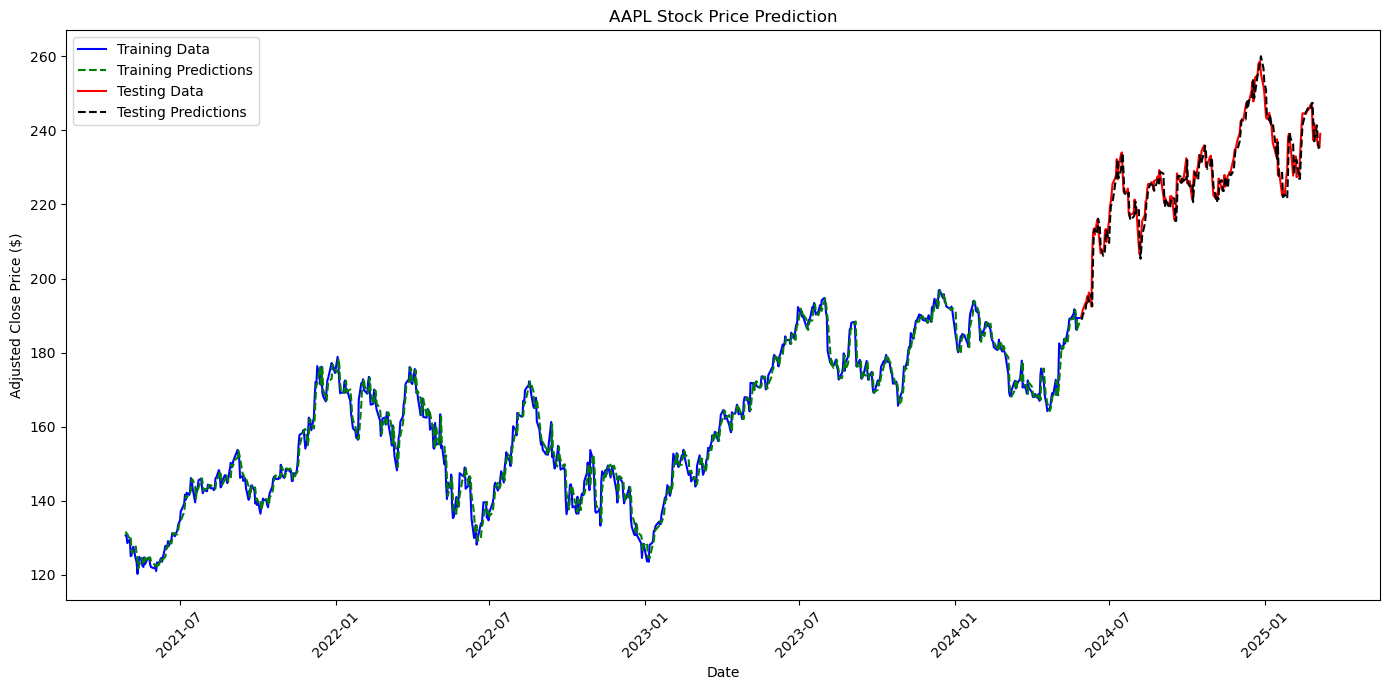

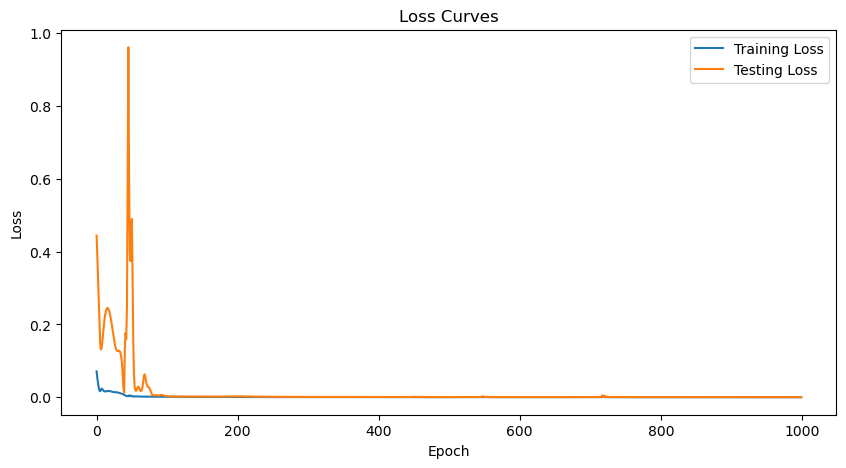

In [39]:
def main():
    now = datetime.now()
    print('Current time:', now.strftime('%Y-%m-%d %H:%M:%S'))
    
    # Select a ticker
    ticker = config['tickers'][0]  # Using AAPL as default
    print(f"Fetching data for {ticker}...")
    
    # Step 1: Create dataset and fetch data
    dataset = StockDataset(config)
    stock_data = dataset.fetch_stock_data(ticker)  # No longer passing dates
    
    # Step 2: Preprocess data
    X_train, y_train, X_test, y_test = dataset.preprocess_data()
    
    print(f"Training data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    
    # Step 3: Create predictor and train model
    predictor = StockPredictor(config)
    predictor.train(X_train, y_train, X_test, y_test)
    
    # Step 4: Make predictions
    train_pred_scaled, test_pred_scaled = predictor.predict(X_train, X_test)
    
    # Step 5: Inverse transform predictions to get actual prices
    train_predictions = dataset.inverse_transform(train_pred_scaled)
    test_predictions = dataset.inverse_transform(test_pred_scaled)
    y_train_actual = dataset.inverse_transform(y_train.cpu().numpy())
    y_test_actual = dataset.inverse_transform(y_test.cpu().numpy())
    
    # Step 6: Get dates for plotting
    train_dates, test_dates = dataset.get_stock_dates_for_plotting(len(y_train), len(y_test))
    
    # Step 7: Visualize results
    predictor.visualize_results(
        train_dates, test_dates,
        train_predictions, test_predictions,
        y_train_actual, y_test_actual,
        ticker
    )
    
    # Save the model (optional)
    # predictor.save_model()

if __name__ == '__main__':
    main()